In [53]:
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [9]:
records = []
segment_id = 0
with open("data//choi_txt_segm.txt", encoding="utf-8") as f:
    for line in f:
        line = line.rstrip("\n")
        if line.strip() == "":
            segment_id += 1   # blank line = new segment
            continue
        sent_id, text = line.split(":", 1)   # split on first colon only
        records.append({

            "text": text.strip()
        })

df = pd.DataFrame(records)
df

,text
0,The Sane Society is an ambitious work .
1,Its scope is as broad as the question : What d...
2,"A work so broad , even when it is directed by ..."
3,Even a hasty reader will easily find in it num...
4,Such books are easy prey for critics .
...,...
94,A two-run homer by Norm Siebern and a solo bla...
95,House throws wild With one down in the eighth ...
96,Catcher Frank House 's throw in an effort to n...
97,"Then Heywood Sullivan , Kansas City catcher , ..."


In [17]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(df['text'].tolist())
df['embeddings'] = list(embeddings) 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [43]:
X = np.stack(df['embeddings'].to_numpy())
np.shape(X)

(99, 384)

In [40]:
model_cluster = KMeans(n_clusters=5).fit(X)

In [59]:
labels = model_cluster.labels_
df['label'] = labels
df = df.sort_values(by=['label'])
df

,text,embeddings,label
92,Siebern hits homer Over the first five frames ...,"[0.076135725, -0.16272776, -0.24073571, -0.038...",0
84,This expectation is what really `` sold '' poi...,"[0.0038770032, -0.13279231, -0.3112863, -0.068...",1
2,"A work so broad , even when it is directed by ...","[0.08726512, -0.12650229, -0.1162967, 0.011209...",1
0,The Sane Society is an ambitious work .,"[0.12119473, 0.32322156, -0.53524554, 0.072229...",1
80,"briefly , the topping configuration must be ex...","[-0.09694916, 0.025434857, -0.065224305, -0.32...",1
...,...,...,...
61,It was Nischwitz ' third straight victory of t...,"[-0.086922295, 0.0639323, -0.21157338, -0.0327...",4
60,"The husky 6-3 , 205-pound lefthander , was in ...","[0.21777034, 0.077581726, -0.36103258, -0.2897...",4
32,She will receive the 1961 `` Oscar '' at the 2...,"[0.04699464, 0.24323605, 0.032356355, 0.247369...",4
33,"The only woman recipient , Miss Garson will re...","[-0.23246501, 0.16499491, 0.046244454, 0.19830...",4


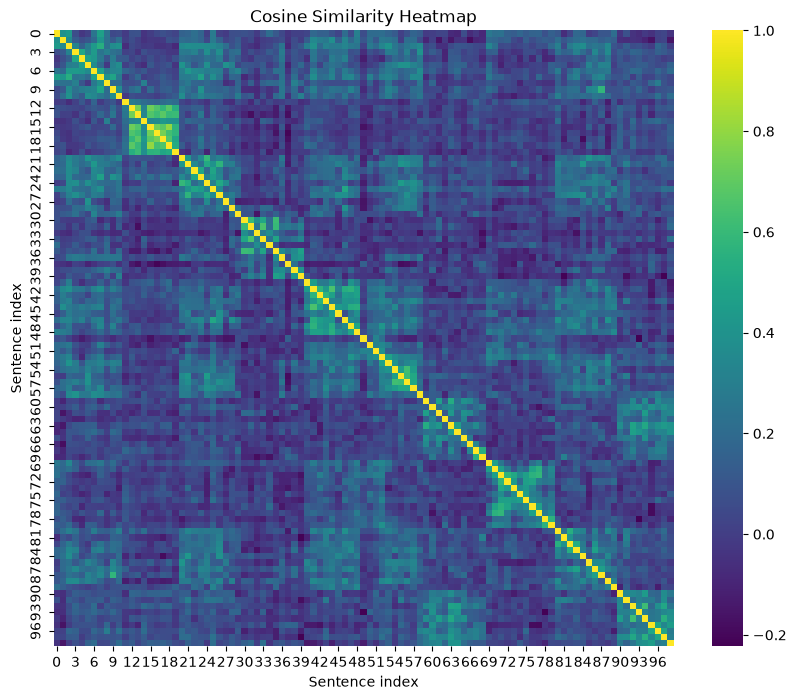

In [58]:
# 2. Normalize each embedding to unit length
norm_emb = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

# 3. Cosine similarity matrix = normalized Gram matrix
cos_sim = norm_emb @ norm_emb.T   # shape (99, 99)

# 4. Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cos_sim, cmap="viridis")
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Sentence index")
plt.ylabel("Sentence index")
plt.show()